In [1]:
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
N = 10000
radius = 5
epsilon = 0.2

In [3]:
xs = np.linspace(-radius, radius, N)
ys = np.sqrt(25 - xs**2) + np.random.normal(scale=1, size=xs.shape[0])

def distance(point, radius):
    x, y = point
    distance_from_origin = np.sqrt(y**2 + x**2)
    distance_from_curve = abs(np.sqrt(y**2 + x**2) - radius)
    return distance_from_curve

In [4]:
samples = []

for x, y in zip(xs, ys):
    if (distance((x,y), radius) <= epsilon):
        samples.append([x, y, 1])
    else:
        samples.append([x, y, 0])

samples = np.array(samples)

positive_samples =  samples[samples[:, 2] == 1]
neg_samples = samples[samples[:, 2] == 0]
np.random.shuffle(neg_samples)
neg_samples = neg_samples[:int(len(positive_samples) * 0.2)]
train_sampels = np.concatenate((positive_samples, neg_samples))
np.random.shuffle(train_sampels)

In [5]:
train_sampels.shape

(2856, 3)

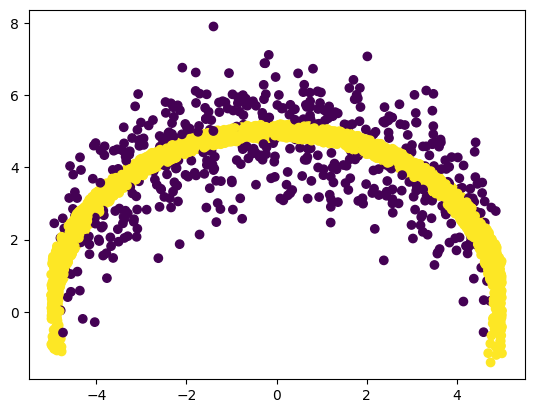

In [6]:
plt.scatter(train_sampels[:, 0], train_sampels[:, 1], c=train_sampels[:, 2])

In [7]:
from torch.utils.data import Dataset, DataLoader

In [8]:
class CircleDataset(Dataset):
    def __init__(self, inputs, labels):
        super().__init__()
        self.inputs = torch.from_numpy(inputs).float()
        self.labels = torch.from_numpy(labels).float().unsqueeze(1)
    
    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]
    
    def __len__(self):
        return len(self.inputs)

In [11]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_layer = nn.Linear(2, 16)
        hidden_layer = nn.Linear(16, 16)
        output_layer = nn.Linear(16, 1)
        self.network = nn.Sequential(input_layer, nn.ReLU(), hidden_layer, nn.ReLU(), output_layer)
    
    def forward(self, x):
        return self.network(x)

In [12]:
model = CircleModel()

In [13]:
def is_on_circle(x, y, debug=False):
    inputs = torch.tensor([x, y]).unsqueeze(0).float()
    with torch.no_grad():
        logit = model(inputs)
        prob = torch.sigmoid(logit).item()

    if debug:
        print(f"Probability {prob * 100:.2f} %")
    
    if prob > 0.95:
        return True
    else:
        return False

In [27]:
import os

In [30]:
# Training
np.random.shuffle(train_sampels)
dataset = CircleDataset(train_sampels[:, [0,1]], train_sampels[:, 2])
dataloader = DataLoader(dataset, batch_size=10, shuffle=True, drop_last=True)

loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epoches = 10000
model.train()

start_epoch = 1

# load if checkpoint exists
if os.path.isfile('checkpoint.pth'):
    checkpoint = torch.load('checkpoint.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    loss = checkpoint['loss']


for epoch in range(start_epoch, epoches + 1):
    lossess = []
    
    # process each batch of inputs
    for idx, (inputs, labels) in enumerate(dataloader):
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        lossess.append(loss.item())
        optimizer.step()
    
    # Print progress
    if (epoch % 100) == 0:
        print(f"Epoch [{epoch}/{epoches}], Avg Loss Per epoch: {np.average(lossess):.4f}")
    
    if epoch % 1000:
        torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,}, 'checkpoint.pth')



Epoch [2400/10000], Avg Loss Per epoch: 0.0500
Epoch [2500/10000], Avg Loss Per epoch: 0.0443
Epoch [2600/10000], Avg Loss Per epoch: 0.0435
Epoch [2700/10000], Avg Loss Per epoch: 0.0506
Epoch [2800/10000], Avg Loss Per epoch: 0.0550
Epoch [2900/10000], Avg Loss Per epoch: 0.0506
Epoch [3000/10000], Avg Loss Per epoch: 0.0616
Epoch [3100/10000], Avg Loss Per epoch: 0.0561
Epoch [3200/10000], Avg Loss Per epoch: 0.0544
Epoch [3300/10000], Avg Loss Per epoch: 0.0452
Epoch [3400/10000], Avg Loss Per epoch: 0.0665
Epoch [3500/10000], Avg Loss Per epoch: 0.0444
Epoch [3600/10000], Avg Loss Per epoch: 0.0580
Epoch [3700/10000], Avg Loss Per epoch: 0.0473
Epoch [3800/10000], Avg Loss Per epoch: 0.0539
Epoch [3900/10000], Avg Loss Per epoch: 0.0453
Epoch [4000/10000], Avg Loss Per epoch: 0.0474
Epoch [4100/10000], Avg Loss Per epoch: 0.0466
Epoch [4200/10000], Avg Loss Per epoch: 0.0447
Epoch [4300/10000], Avg Loss Per epoch: 0.0474
Epoch [4400/10000], Avg Loss Per epoch: 0.0517
Epoch [4500/1

In [31]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 337


In [32]:
# save model to disk
torch.save(model.state_dict(), 'circle_model_337.pth')

In [33]:
# load model from disk
if os.path.isfile('circle_model_337.pth'):
    model1 = CircleModel()
    model1.load_state_dict(torch.load('circle_model_337.pth'))
    model1.eval()

In [34]:
def accuracy(sampels):
    total = 0
    success = 0
    for x, y, actual in sampels:
        actual = True if actual > 0 else False
        total += 1
        if is_on_circle(x, y) == actual:
            success += 1

    print(f"Accuracy {success/total*100:.2f}")

In [35]:
model.eval()
accuracy(train_sampels)
accuracy(samples)

Accuracy 96.88
Accuracy 97.38
